<a href="https://colab.research.google.com/github/victormaciase/EconometriaFinanciera_MagisterFinanzasWK/blob/main/Lab11/Lab11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratorio 11**

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
!pip install -q pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 3.3 MB/s eta 0:00:00


In [3]:
import yfinance as yf
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX

## **Pregunta 1**

Importa los datos mensuales de ventas de energía a clientes regulados y libres.

In [4]:
url_data = "https://raw.githubusercontent.com/victormaciase/EconometriaFinanciera_MagisterFinanzasWK/refs/heads/main/Lab11/ventas_energia.csv"

energia = pd.read_csv(
    url_data,
    parse_dates=['fecha'],
    index_col='fecha'
)

## **Pregunta 2**

Muestra las primeras 10 observaciones y las últimas 10 observaciones.

In [5]:
energia.head(10)

,regulado,total,libre
fecha,,,
2019-01-01,2623225.0,6114416.0,3491191.0
2019-02-01,2353357.0,5587455.0,3234098.0
2019-03-01,2647858.0,6106213.0,3458355.0
2019-04-01,2552990.0,5712528.0,3159538.0
2019-05-01,2704160.0,6069605.0,3365444.0
2019-06-01,2573878.0,6005979.0,3432101.0
2019-07-01,2743613.0,6299094.0,3555481.0
2019-08-01,2726129.0,6118728.0,3392599.0
2019-09-01,2617200.0,5663030.0,3045831.0


In [6]:
energia.tail(10)

,regulado,total,libre
fecha,,,
2025-09-01,2408549.0,6274936.0,3866386.0
2025-10-01,2413778.0,6545143.0,4131365.0
2025-11-01,2395864.0,6508107.0,4112242.0
2025-12-01,2623320.0,7008842.0,4385522.0
2026-01-01,2752849.0,6975596.0,4222747.0
2026-02-01,2422912.0,6296603.0,3873691.0
2026-03-01,2550724.0,6938871.0,4388147.0
2026-04-01,2386447.0,6444639.0,4058192.0
2026-05-01,2683368.0,6855056.0,4171688.0


## **Pregunta 3**

Grafica la serie de ventas a clientes regulados (en TWh), la función de autocorrelación y la función de autocorrelación parcial.

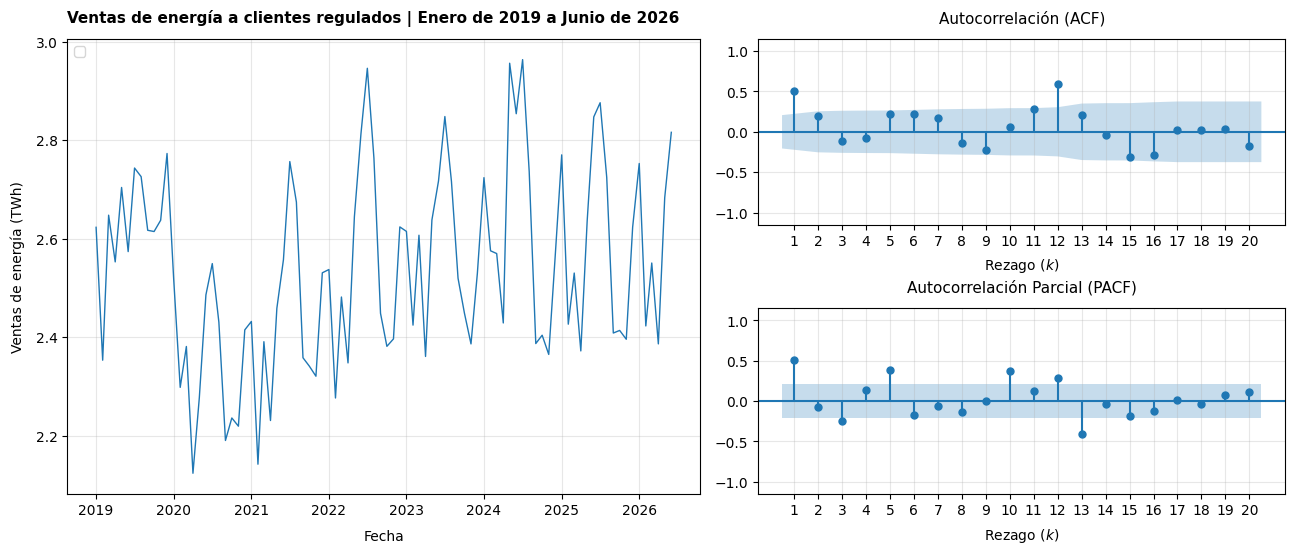

In [7]:
ventas_reguladas = energia["regulado"] / 1000000

# Gráficos
fig = plt.figure(figsize=(14, 5))

gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1], hspace=0.45, wspace=0.1)

lags_mostrar = 20

# COLUMNA 1:
ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(
    ventas_reguladas.index,
    ventas_reguladas.values,
    color="#1f77b4",
    linewidth=1,
)
ax1.set_title(
    'Ventas de energía a clientes regulados | Enero de 2019 a Junio de 2026', loc='left',
    fontsize=11,
    fontweight="bold",
    pad=12,
)
ax1.set_xlabel("Fecha", labelpad=8)
ax1.set_ylabel("Ventas de energía (TWh)", labelpad=8)
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

# COLUMNA 2 (superior): ACF
ax2 = fig.add_subplot(gs[0, 1])
plot_acf(
    ventas_reguladas,
    ax=ax2,
    lags=lags_mostrar,
    zero=False,
    title="Autocorrelación (ACF)",
)
ax2.set_title("Autocorrelación (ACF)", fontsize=11, pad=12)
ax2.set_xlabel("Rezago ($k$)", labelpad=6)
ax2.set_xticks(range(1, lags_mostrar + 1))

ax2.set_ylim(-1.15, 1.15)
ax2.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])
ax2.grid(True, alpha=0.3)

# COLUMNA 2 (Inferior): PACF
ax3 = fig.add_subplot(gs[1, 1])
plot_pacf(
    ventas_reguladas,
    ax=ax3,
    lags=lags_mostrar,
    zero=False,
    title="Autocorrelación Parcial (PACF)",
    method="ywm",
)
ax3.set_title("Autocorrelación Parcial (PACF)", fontsize=11, pad=12)
ax3.set_xlabel("Rezago ($k$)", labelpad=6)
ax3.set_xticks(range(1, lags_mostrar + 1))
ax3.set_ylim(-1.15, 1.15)
ax3.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])
ax3.grid(True, alpha=0.3)


plt.subplots_adjust(top=0.92, bottom=0.01, left=0.08, right=0.95)

plt.show()

## **Pregunta 4**

¿Es estacionaria la serie de ventas de energía a clientes regulados? Si no es estacionaria, ¿Cómo convertir la serie en estacionaria?

In [8]:
adf_ventas_reguladas= adfuller(ventas_reguladas, regression='c')
print(f"Ventas de energía a clientes regulados | p-value: {adf_ventas_reguladas[1]:.4f} | {'No Estacionaria' if adf_ventas_reguladas[1] >= 0.05 else 'Estacionaria'}")



Ventas de energía a clientes regulados | p-value: 0.3235 | No Estacionaria


In [9]:
adf_ventas_reguladas_diff12 = adfuller(ventas_reguladas.diff(12).diff(1).dropna(), regression='c')
print(f"Ventas de energía a clientes regulados | p-value: {adf_ventas_reguladas_diff12[1]:.4f} | {'No Estacionaria' if adf_ventas_reguladas_diff12[1] >= 0.05 else 'Estacionaria'}")


Ventas de energía a clientes regulados | p-value: 0.0000 | Estacionaria


## **Pregunta 5**

Separa los datos en conjunto de datos de entrenamiento (80%) y de prueba (20%)

In [10]:
train_size = int(len(ventas_reguladas) * 0.80)
train_regulados = ventas_reguladas.iloc[:train_size]
test_regulados = ventas_reguladas.iloc[train_size:]



In [11]:
test_regulados.head()

,regulado
fecha,
2025-01-01,2.770358
2025-02-01,2.426494
2025-03-01,2.530349
2025-04-01,2.372191
2025-05-01,2.636440


In [12]:
test_regulados.tail()

,regulado
fecha,
2026-02-01,2.422912
2026-03-01,2.550724
2026-04-01,2.386447
2026-05-01,2.683368
2026-06-01,2.816178


## **Pregunta 6**

Usando la función `auto_arima` selecciona un modelo para las ventas de energía a clientes regulados. ¿Eligen el mismo modelo los criterios de información de Akaike y el Bayesiano?

In [13]:
np.random.seed(318)

modelo_regulados_aic = pm.auto_arima(
    train_regulados,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    d=1,  # Diferencia regular
    D=1,  # Diferencia estacional (reflejada en el grafico DD12)
    m=12,  # Datos de frecuencia mensual
    seasonal=True,
    information_criterion='aic',
    random_state=318,
    n_jobs=1,
    stepwise=True,
    suppress_warnings=True,
)

print(f'Modelo óptimo por AIC: ARIMA{modelo_regulados_aic.order}')
print(modelo_regulados_aic.summary())

Modelo óptimo por AIC: ARIMA(0, 1, 0)
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                   72
Model:             SARIMAX(0, 1, 0)x(1, 1, 0, 12)   Log Likelihood                  50.254
Date:                            Fri, 25 Sep 2026   AIC                            -96.508
Time:                                    19:53:08   BIC                            -92.352
Sample:                                01-01-2019   HQIC                           -94.886
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12      -0.4912      0.138     -3.564      0.000      -0.761      -0.2

In [14]:
np.random.seed(318)

modelo_regulados_bic = pm.auto_arima(
    train_regulados,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    d=1,  # Diferencia regular
    D=1,  # Diferencia estacional (reflejada en el grafico DD12)
    m=12,  # Datos de frecuencia mensual
    seasonal=True,
    information_criterion='bic',
    random_state=318,
    n_jobs=1,
    stepwise=True,
    suppress_warnings=True,
)

print(f'Modelo óptimo por BIC: ARIMA{modelo_regulados_bic.order}')
print(modelo_regulados_bic.summary())

Modelo óptimo por BIC: ARIMA(0, 1, 0)
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                   72
Model:             SARIMAX(0, 1, 0)x(1, 1, 0, 12)   Log Likelihood                  50.254
Date:                            Fri, 25 Sep 2026   AIC                            -96.508
Time:                                    19:53:17   BIC                            -92.352
Sample:                                01-01-2019   HQIC                           -94.886
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12      -0.4912      0.138     -3.564      0.000      -0.761      -0.2

## **Pregunta 7**

Usando el modelo seleccionado SARIMA $(0,1,0) \times (1,1,0)_{12}$, realiza proyecciones de las ventas de energía en el *test set*. Grafica la serie observada y predicha.

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


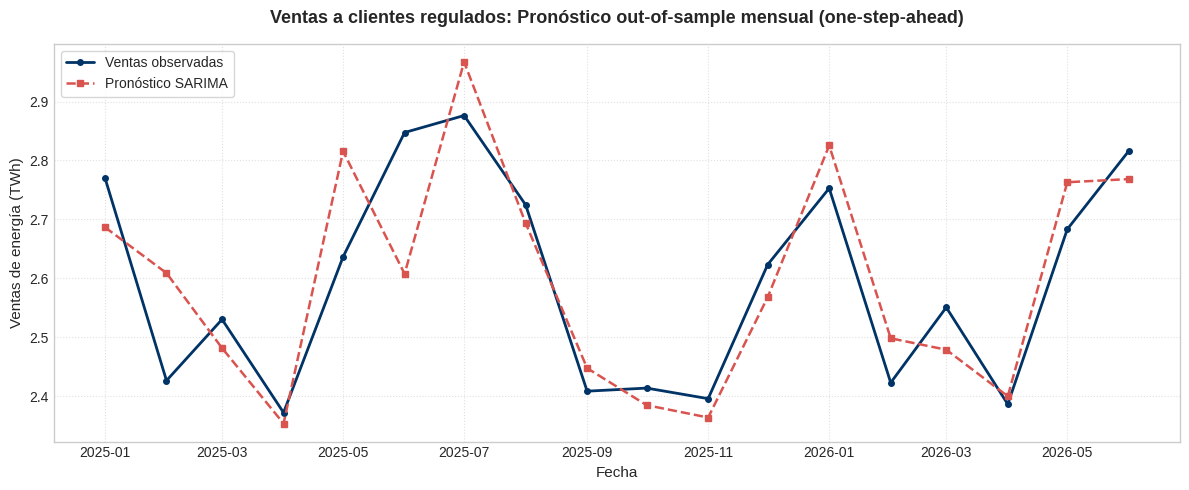

In [17]:

history_ventas = list(train_regulados)
pred_ventas = []

for date in test_regulados.index:
    # Ajuste del modelo SARIMA $(0,1,0) \times (1,1,0)_{12}$
    model = SARIMAX(
        history_ventas,
        order=(0, 1, 0),
        seasonal_order=(1, 1, 0, 12),
        trend='n',  # Sin constante
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    model_fit = model.fit(disp=False)

    # Pronóstico a 1 mes vista (t+1)
    y_hat = model_fit.forecast(steps=1)[0]
    pred_ventas.append(y_hat)

    # Actualizar la ventana rodante agregando el dato real observado este mes
    history_ventas.append(test_regulados.loc[date])

# DataFrame
ventas_results_df = pd.DataFrame(
    {'Ventas_Observadas': test_regulados.values, 'Ventas_Predichas': pred_ventas},
    index=test_regulados.index,
)

# Gráfico del Pronóstico Out-of-Sample en Ventana Rodante
plt.style.use(
    'seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid' in plt.style.available
    else 'default'
)
plt.figure(figsize=(12, 5))

plt.plot(
    ventas_results_df.index,
    ventas_results_df['Ventas_Observadas'],
    label='Ventas observadas',
    color='#003366',
    linewidth=2.0,
    marker='o',
    markersize=4,
)
plt.plot(
    ventas_results_df.index,
    ventas_results_df['Ventas_Predichas'],
    label=f'Pronóstico SARIMA',
    color='#D9534F',
    linestyle='--',
    linewidth=1.8,
    marker='s',
    markersize=4,
)

plt.title(
    'Ventas a clientes regulados: Pronóstico out-of-sample mensual (one-step-ahead)',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Fecha', fontsize=11)
plt.ylabel('Ventas de energía (TWh)', fontsize=11)
plt.legend(loc='upper left', frameon=True, fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## **Pregunta 8**

Calcula el RMSE y MAE

In [16]:
rmse_ventas = np.sqrt(
    np.mean((ventas_results_df['Ventas_Observadas'] - ventas_results_df['Ventas_Predichas'])** 2
    )
)
mae_ventas = np.mean(
    np.abs(
        ventas_results_df['Ventas_Observadas'] - ventas_results_df['Ventas_Predichas']
    )
)

print(
    'EVALUACIÓN PRONÓSTICO VENTAS A CLIENTES REGULADOS'
)
print(f'RMSE: {rmse_ventas:.4f} TWh')
print(f'MAE:  {mae_ventas:.4f} TWh')

EVALUACIÓN PRONÓSTICO VENTAS A CLIENTES REGULADOS
RMSE: 0.0981 TWh
MAE:  0.0772 TWh
